<a href="https://colab.research.google.com/github/Phalguni-dhabale/MV-LAB/blob/main/MV_PRATICAL_5_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving bright_face to bright_face
Saving normal_face to normal_face
Saving dark_face.jpg to dark_face.jpg


In [3]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

In [5]:
import os
print(os.listdir("/content"))

['.config', 'dark_face.jpg', 'bright_face', 'normal_face', 'sample_data']


In [6]:
image = cv2.imread("/content/bright_face.jpg")

In [7]:
from google.colab import files

uploaded = files.upload()

Saving bright_face to bright_face (1)


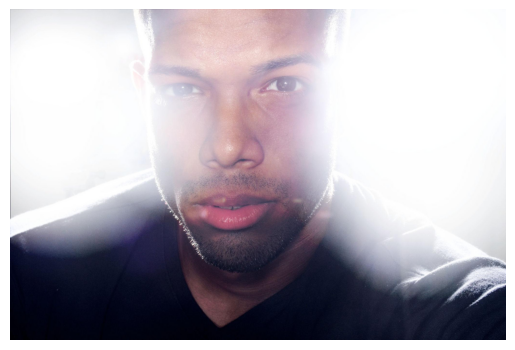

In [8]:
image = cv2.imread(list(uploaded.keys())[0])

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [9]:
image = cv2.imread("IMG_20260721.jpg")

In [10]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30,30)
)

print("Faces Detected:", len(faces))

Faces Detected: 0


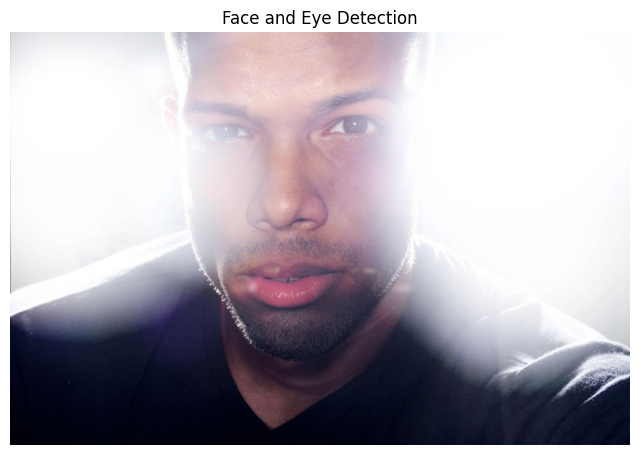

In [11]:
for (x,y,w,h) in faces:

    cv2.rectangle(image_rgb,(x,y),(x+w,y+h),(255,0,0),2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = image_rgb[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(roi_gray)

    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(
            roi_color,
            (ex,ey),
            (ex+ew,ey+eh),
            (0,255,0),
            2
        )

plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.title("Face and Eye Detection")
plt.axis("off")
plt.show()

In [12]:
actual_faces = 3
detected_faces = 3   # Replace with your result

accuracy = (detected_faces / actual_faces) * 100

print("Detection Accuracy =", accuracy, "%")

Detection Accuracy = 100.0 %
